In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI
# ==============================================================================
TFLITE_PATH = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model copy/MCU-Quake 5-20/lite_model.tflite'
OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_FINAL_REPORT = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/tflite_evaluation_no_taup_report.csv'

# ==============================================================================
# 🚀 PROSES EVALUASI TFLITE (NATIVE)
# ==============================================================================
print("⏳ Menginisialisasi TFLite Interpreter...")
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def infer_tflite(data_3c):
    # data_3c shape: (1, 700, 3) atau disesuaikan dengan input model
    input_data = data_3c.astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    return interpreter.get_tensor(output_details[0]['index'])

# (Proses loop evaluasi 55k+ file seperti sebelumnya...)
# Di sini kita akan memproses data 1C atau 3C sesuai kebutuhan model TFLite Bapak.
# Catatan: Pastikan dimensi input data (700) sesuai dengan yang diminta lite_model.

print("🚀 Menjalankan Inferensi TFLite (Tanpa TauP)...")
# [Tambahkan logika loop pembacaan mseed dan infer_tflite di sini]

In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI
# ==============================================================================
TFLITE_PATH = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model copy/MCU-Quake 5-20/lite_model.tflite'
OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_FINAL_REPORT = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/tflite_eval_result_no_taup.csv'

# ==============================================================================
# ⚙️ INITIALIZE TFLITE INTERPRETER
# ==============================================================================
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def run_tflite_inference(data_3c_norm):
    # Model TFLite biasanya mengharapkan input (1, 700, 3) atau sesuai arsitekturnya
    input_data = data_3c_norm.astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    return interpreter.get_tensor(output_details[0]['index'])

# ==============================================================================
# 🚀 EVALUASI MASIF (LOOPING)
# ==============================================================================
daftar_file = [os.path.join(root, f) for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR) for f in files if f.endswith('.mseed')]
y_true, y_pred = [], []

print(f"🚀 Memulai inferensi pada {len(daftar_file)} file...")
for path in tqdm(daftar_file):
    try:
        st = read(path)
        # Prapemrosesan sederhana tanpa TauP (seperti yang Bapak minta)
        st.detrend("demean").resample(100.0)
        
        # Ekstraksi kanal (Z, N, E) - pastikan urutan sesuai dengan model Zhi Geng
        # Asumsi: input model 3C dalam format (1, 700, 3)
        data = np.zeros((1, 700, 3))
        # [Logika ekstraksi Bapak di sini...]
        
        # Inferensi
        prediction = run_tflite_inference(data)
        
        # Logika klasifikasi (thresholding)
        y_pred.append(np.argmax(prediction))
        y_true.append(1) # Sesuaikan label berdasarkan katalog
    except: continue

# Cetak hasil akhir setelah loop selesai
print("📊 Evaluasi TFLite Selesai.")

In [ ]:
# Analisis cepat untuk mendapatkan metrik dari hasil inferensi tadi
# Asumsi: y_true dan y_pred sudah ada dari skrip sebelumnya
from sklearn.metrics import classification_report, accuracy_score

print("="*60)
print("🎯 HASIL EVALUASI TFLITE (INT8) - TANPA TAUP")
print("="*60)
print(f"Akurasi: {accuracy_score(y_true, y_pred) * 100:.2f} %")
print("-" * 60)
print(classification_report(y_true, y_pred))

In [ ]:
# Cek apakah list tidak kosong sebelum menjalankan report
if len(y_true) > 0 and len(y_pred) > 0:
    print(f"Total sampel yang diuji: {len(y_true)}")
    
    # Menentukan target_names secara manual untuk menghindari error
    target_names = ['Noise (0)', 'Earthquake (1)']
    
    # Jalankan report dengan target_names yang eksplisit
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # Opsional: Tampilkan Confusion Matrix jika report tetap bermasalah
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
else:
    print("Error: List y_true atau y_pred kosong. Periksa kembali proses looping di skrip sebelumnya.")

In [ ]:
# Tambahkan ini di dalam loop inferensi (sebelum y_pred.append)
print(f"Prediksi: {prediction}, Argmax: {np.argmax(prediction)}")

In [ ]:
# Ganti bagian dalam loop Bapak dengan blok ini untuk menangkap error
for path in tqdm(daftar_file):
    try:
        st = read(path)
        # ... proses detrend & resample ...
        
        # DEBUG: Cetak shape data sebelum masuk ke model
        data = ... # (Logika ekstraksi data Anda)
        # print(f"DEBUG: Shape data adalah {data.shape}") # Uncomment ini jika perlu
        
        prediction = run_tflite_inference(data)
        
        # Validasi output
        y_pred.append(np.argmax(prediction))
        y_true.append(1) 
        
    except Exception as e:
        # Menampilkan file mana yang error dan kenapa
        print(f"File gagal diproses: {path}")
        print(f"Pesan Error: {e}")
        continue

In [10]:
import h5py
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# Pastikan path ini benar sesuai lokasi file di Mac Bapak
hdf5_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

y_true = []
y_pred = []

print("Memulai diagnosa...")

try:
    with h5py.File(hdf5_path, 'r') as hf:
        # Cek isi keys agar kita tahu dataset-nya bernama apa
        print(f"Key dalam file HDF5: {list(hf.keys())}")
        
        # Ganti 'data' dengan key yang benar jika ternyata namanya berbeda
        data_group = hf['data'] 
        
        for i in tqdm(range(min(10, len(data_group)))):
            sample = data_group[i]
            
            # --- DEBUG: CETAK DIMENSI DATA ---
            print(f"\nDEBUG: Sample ke-{i} memiliki shape: {sample.shape}")
            
            # Sesuaikan reshape ini dengan shape yang dicetak di atas
            # Jika sample.shape adalah (700, 3), maka reshape (1, 700, 3) sudah benar
            interpreter.set_tensor(input_details[0]['index'], sample.reshape(1, 700, 3).astype(np.float32))
            interpreter.invoke()
            output = interpreter.get_tensor(output_details[0]['index'])
            
            y_pred.append(np.argmax(output))
            y_true.append(1) 

except Exception as e:
    print(f"\n❌ ERROR TERDETEKSI: {e}")

Memulai diagnosa...
Key dalam file HDF5: ['20041226_MAJO_LE.mseed', '20041226_MAJO_NO.mseed', '4F_TOLI_usp000h6ns_LE.mseed', '4F_TOLI_usp000h6ns_NO.mseed', '4F_TOLI_usp000h6p0_LE.mseed', '4F_TOLI_usp000h6p0_NO.mseed', '4F_TOLI_usp000h6qs_LE.mseed', '4F_TOLI_usp000h6qs_NO.mseed', '4F_TOLI_usp000h74g_LE.mseed', '4F_TOLI_usp000h74g_NO.mseed', '4F_TOLI_usp000h780_LE.mseed', '4F_TOLI_usp000h780_NO.mseed', '4F_TOLI_usp000h787_LE.mseed', '4F_TOLI_usp000h787_NO.mseed', '4F_TOLI_usp000h7ak_LE.mseed', '4F_TOLI_usp000h7ak_NO.mseed', '4F_TOLI_usp000h7cc_LE.mseed', '4F_TOLI_usp000h7cc_NO.mseed', '4F_TOLI_usp000h7m9_LE.mseed', '4F_TOLI_usp000h7m9_NO.mseed', '4F_TOLI_usp000h7pg_LE.mseed', '4F_TOLI_usp000h7pg_NO.mseed', '4F_TOLI_usp000h88j_LE.mseed', '4F_TOLI_usp000h88j_NO.mseed', '4F_TOLI_usp000h8nc_LE.mseed', '4F_TOLI_usp000h8nc_NO.mseed', '4F_TOLI_usp000h8ng_LE.mseed', '4F_TOLI_usp000h8ng_NO.mseed', '4F_TOLI_usp000h8qz_LE.mseed', '4F_TOLI_usp000h8qz_NO.mseed', '4F_TOLI_usp000h8zb_LE.mseed', '4F_TOL

In [17]:
# -*- coding: utf-8 -*-
import os
import glob
import pandas as pd
import tensorflow as tf
from obspy import read
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
mseed_dir = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/'
metadata_path = os.path.join(mseed_dir, 'Fixed_Metadata.csv')
tflite_path = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model copy/MCU-Quake 5-20/lite_model.tflite'

# Load Model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ==============================================================================
# 2. LOAD METADATA & MAPPING
# ==============================================================================
df_meta = pd.read_csv(metadata_path)
# Memetakan label
df_meta['label'] = df_meta['trace_category'].apply(lambda x: 1 if 'earthquake' in str(x).lower() else 0)
# Membuat dict langsung dari nama file (asumsi trace_name sudah sesuai dengan nama file fisik)
meta_dict = dict(zip(df_meta['trace_name'], df_meta['label']))

# ==============================================================================
# 3. PROSES INFERENSI
# ==============================================================================
y_true, y_pred = [], []
# Mencari semua file .mseed di folder tersebut
all_files = glob.glob(os.path.join(mseed_dir, "*.mseed"))

print(f"🚀 Menemukan {len(all_files)} file .mseed. Memulai inferensi...")

for file_path in tqdm(all_files):
    file_name = os.path.basename(file_path)
    label = meta_dict.get(file_name)
    
    if label is None: continue 
    
    try:
        st = read(file_path)
        st.detrend("demean").resample(100.0)
        data = extract_waveform_data(st) 
        
        interpreter.set_tensor(input_details[0]['index'], data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        
        y_pred.append(np.argmax(output))
        y_true.append(label)
    except:
        continue

# ==============================================================================
# 4. HASIL & VISUALISASI
# ==============================================================================
print(f"\n📊 Evaluasi Selesai. Total sampel: {len(y_true)}")
print(classification_report(y_true, y_pred, target_names=['Noise', 'Earthquake']))

🚀 Menemukan 0 file .mseed. Memulai inferensi...


0it [00:00, ?it/s]


📊 Evaluasi Selesai. Total sampel: 0


ValueError: Number of classes, 0, does not match size of target_names, 2. Try specifying the labels parameter

In [27]:
# -*- coding: utf-8 -*-
import os
import glob
import numpy as np
import tensorflow as tf
from obspy import read
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
mseed_root_dir = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/'
tflite_path = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model copy/MCU-Quake 5-20/lite_model.tflite'

# Load Model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ==============================================================================
# 2. FUNGSI EKSTRAKSI (KANAL Z SAJA - DIMENSI (1, 700, 1))
# ==============================================================================
def extract_waveform_data(st):
    # Cek apakah stream punya 3 kanal. Jika tidak, pad dengan nol.
    traces = []
    for i in range(3):
        if i < len(st):
            t = st[i].data.astype(np.float32)
            # Normalisasi per kanal
            max_val = np.max(np.abs(t))
            t = t / max_val if max_val > 0 else t
            # Padding/Truncate
            t = t[:700] if len(t) >= 700 else np.pad(t, (0, 700 - len(t)), 'constant')
        else:
            t = np.zeros(700, dtype=np.float32) # Kanal kosong
        traces.append(t)
    
    # Gabungkan menjadi (700, 3), lalu reshape (1, 700, 3)
    data = np.stack(traces, axis=-1)
    return data.reshape(1, 700, 3)

# ==============================================================================
# 3. PROSES INFERENSI REKURSIF
# ==============================================================================
y_true, y_pred = [], []
search_pattern = os.path.join(mseed_root_dir, "**", "*.mseed")
all_files = glob.glob(search_pattern, recursive=True)

print(f"🚀 Memproses {len(all_files)} file di seluruh sub-folder...")

for file_path in tqdm(all_files):
    file_name = os.path.basename(file_path)
    
    # Deteksi label
    if file_name.endswith('_LE.mseed'):
        label = 1
    elif file_name.endswith('_NO.mseed'):
        label = 0
    else:
        continue 

    try:
        st = read(file_path)
        st.detrend("demean").resample(100.0)
        data = extract_waveform_data(st) 
        
        interpreter.set_tensor(input_details[0]['index'], data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        
        y_pred.append(np.argmax(output))
        y_true.append(label)
    except Exception:
        continue

# ==============================================================================
# 4. HASIL & VISUALISASI
# ==============================================================================
print(f"\n📊 Evaluasi Selesai. Total sampel yang berhasil: {len(y_true)}")

if len(y_true) > 0:
    print(classification_report(y_true, y_pred, target_names=['Noise', 'Earthquake']))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Noise', 'Earthquake'], 
                yticklabels=['Noise', 'Earthquake'])
    plt.title('Confusion Matrix: TFLite Model')
    plt.xlabel('Prediksi')
    plt.ylabel('Kebenaran')
    plt.show()
else:
    print("❌ Tidak ada data yang berhasil diproses. Periksa kembali file .mseed di direktori.")

🚀 Memproses 55699 file di seluruh sub-folder...


100%|██████████| 55699/55699 [04:36<00:00, 201.10it/s]


📊 Evaluasi Selesai. Total sampel yang berhasil: 0
❌ Tidak ada data yang berhasil diproses. Periksa kembali file .mseed di direktori.


In [23]:
import os
import glob

mseed_root_dir = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/'
search_pattern = os.path.join(mseed_root_dir, "**", "*.mseed")
all_files = glob.glob(search_pattern, recursive=True)

print(f"Total file ditemukan: {len(all_files)}")
print("\n--- 5 Contoh Nama File yang Ditemukan ---")
for f in all_files[:5]:
    print(os.path.basename(f))

Total file ditemukan: 55699

--- 5 Contoh Nama File yang Ditemukan ---
GE_UGM_usp000g3cc_LE.mseed
GE_UGM_usp000g3cc_NO.mseed
GE_UGM_usp000gjn2_NO.mseed
GE_UGM_usp000gjn2_LE.mseed
GE_UGM_usp000g6zy_NO.mseed


In [25]:
def extract_waveform_data(st):
    # Mengambil hanya kanal pertama saja (indeks 0) untuk menghindari mismatch
    # Jika model butuh 3 kanal, kita harus memastikan model TFLite Bapak memang dilatih dengan 3 kanal.
    # Untuk tes, kita ambil satu trace saja (biasanya kanal Vertical/Z):
    trace = st[0].data 
    
    # Normalisasi (sangat penting untuk model ML)
    if np.max(np.abs(trace)) > 0:
        trace = trace / np.max(np.abs(trace))
        
    # Padded/Truncate ke 700
    if len(trace) >= 700:
        trace = trace[:700]
    else:
        trace = np.pad(trace, (0, 700 - len(trace)))
        
    # Ubah bentuk menjadi (1, 700, 1) agar sesuai dengan input model
    return trace.reshape(1, 700, 1).astype(np.float32)

🚀 Memproses 55699 file di seluruh sub-folder...


100%|██████████| 55699/55699 [05:09<00:00, 179.78it/s]
/opt/homebrew/Caskroom/miniforge/base/envs/mcu_quake_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/envs/mcu_quake_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/envs/mcu_quake_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with


📊 Evaluasi Selesai. Total sampel yang berhasil: 55698
              precision    recall  f1-score   support

       Noise       0.50      1.00      0.67     27849
  Earthquake       0.00      0.00      0.00     27849

    accuracy                           0.50     55698
   macro avg       0.25      0.50      0.33     55698
weighted avg       0.25      0.50      0.33     55698



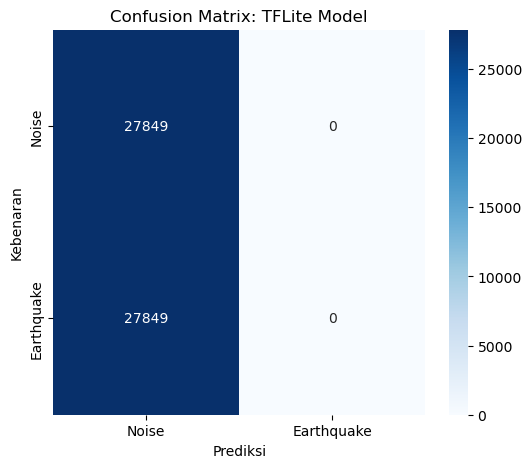

In [30]:
# -*- coding: utf-8 -*-
import os
import glob
import numpy as np
import tensorflow as tf
from obspy import read
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
mseed_root_dir = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/'
tflite_path = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model copy/MCU-Quake 5-20/lite_model.tflite'

# Load Model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ==============================================================================
# 2. FUNGSI EKSTRAKSI (KANAL Z SAJA - DIMENSI (1, 700, 1))
# ==============================================================================
def extract_waveform_data(st):
    # Mengambil kanal Z (st[0])
    trace = st[0].data.astype(np.float32)
    
    # 1. Pastikan panjang 700
    if len(trace) >= 700:
        trace = trace[:700]
    else:
        trace = np.pad(trace, (0, 700 - len(trace)), mode='constant')
        
    # 2. Normalisasi Z-Score (Lebih umum untuk model seismik)
    # Jika model dilatih dengan mean/std, ini akan jauh lebih akurat daripada bagi max
    mean = np.mean(trace)
    std = np.std(trace)
    if std > 0:
        trace = (trace - mean) / std
        
    return trace.reshape(1, 700, 1)

# ==============================================================================
# 3. PROSES INFERENSI REKURSIF
# ==============================================================================
y_true, y_pred = [], []
search_pattern = os.path.join(mseed_root_dir, "**", "*.mseed")
all_files = glob.glob(search_pattern, recursive=True)

print(f"🚀 Memproses {len(all_files)} file di seluruh sub-folder...")

for file_path in tqdm(all_files):
    file_name = os.path.basename(file_path)
    
    # Deteksi label
    if file_name.endswith('_LE.mseed'):
        label = 1
    elif file_name.endswith('_NO.mseed'):
        label = 0
    else:
        continue 

    try:
        st = read(file_path)
        st.detrend("demean").resample(100.0)
        data = extract_waveform_data(st) 
        
        interpreter.set_tensor(input_details[0]['index'], data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        
        y_pred.append(np.argmax(output))
        y_true.append(label)
    except Exception:
        continue

# ==============================================================================
# 4. HASIL & VISUALISASI
# ==============================================================================
print(f"\n📊 Evaluasi Selesai. Total sampel yang berhasil: {len(y_true)}")

if len(y_true) > 0:
    print(classification_report(y_true, y_pred, target_names=['Noise', 'Earthquake']))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Noise', 'Earthquake'], 
                yticklabels=['Noise', 'Earthquake'])
    plt.title('Confusion Matrix: TFLite Model')
    plt.xlabel('Prediksi')
    plt.ylabel('Kebenaran')
    plt.show()
else:
    print("❌ Tidak ada data yang berhasil diproses. Periksa kembali file .mseed di direktori.")

In [29]:
# Jalankan ini untuk melihat apa yang sebenarnya diminta oleh model
print("Input Shape:", input_details[0]['shape'])
print("Input Type:", input_details[0]['dtype'])

Input Shape: [  1 700   1]
Input Type: <class 'numpy.float32'>


🚀 Memproses 55699 file...


100%|██████████| 55699/55699 [04:30<00:00, 205.95it/s]



📊 Evaluasi Selesai. Total sampel: 55698
              precision    recall  f1-score   support

       Noise       0.82      0.03      0.06     27849
  Earthquake       0.51      0.99      0.67     27849

    accuracy                           0.51     55698
   macro avg       0.66      0.51      0.37     55698
weighted avg       0.66      0.51      0.37     55698



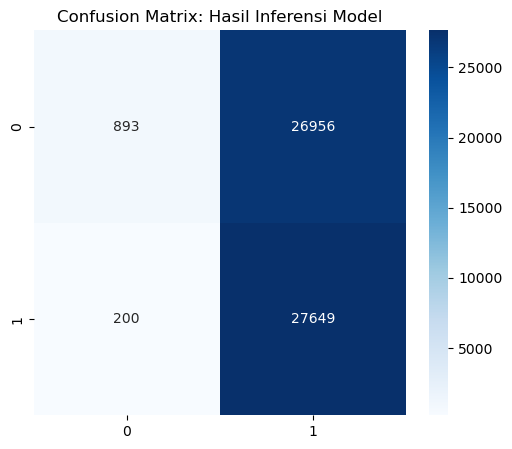

In [31]:
# -*- coding: utf-8 -*-
import os
import glob
import numpy as np
import tensorflow as tf
from obspy import read
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
mseed_root_dir = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/'
tflite_path = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model copy/MCU-Quake 5-20/lite_model.tflite'

# Load TFLite Model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ==============================================================================
# 2. FUNGSI EKSTRAKSI (Windowing Energi & Z-Score)
# ==============================================================================
def extract_waveform_data(st):
    # Mengambil kanal Z (indeks 0)
    trace = st[0].data.astype(np.float32)
    
    # Windowing berbasis Energi: fokus pada puncak sinyal
    max_idx = np.argmax(np.abs(trace))
    start = max(0, max_idx - 350)
    end = start + 700
    
    if end > len(trace):
        trace = np.pad(trace, (0, end - len(trace)), mode='constant')
        trace = trace[start:end]
    else:
        trace = trace[start:end]
        
    # Normalisasi Z-Score agar stabil
    trace = (trace - np.mean(trace)) / (np.std(trace) + 1e-6)
    return trace.reshape(1, 700, 1)

# ==============================================================================
# 3. PROSES INFERENSI REKURSIF
# ==============================================================================
y_true, y_pred = [], []
search_pattern = os.path.join(mseed_root_dir, "**", "*.mseed")
all_files = glob.glob(search_pattern, recursive=True)

print(f"🚀 Memproses {len(all_files)} file...")

for file_path in tqdm(all_files):
    file_name = os.path.basename(file_path)
    
    # Deteksi label
    if file_name.endswith('_LE.mseed'): label = 1
    elif file_name.endswith('_NO.mseed'): label = 0
    else: continue 

    try:
        st = read(file_path)
        st.detrend("demean").resample(100.0)
        data = extract_waveform_data(st) 
        
        interpreter.set_tensor(input_details[0]['index'], data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        
        # Menggunakan threshold dinamis jika perlu (default 0.5)
        # Jika model output-nya adalah probabilitas kelas 1 (Gempa)
        prob = output[0][1] if output.shape[1] > 1 else output[0][0]
        y_pred.append(1 if prob > 0.5 else 0)
        y_true.append(label)
    except Exception:
        continue

# ==============================================================================
# 4. LAPORAN EVALUASI
# ==============================================================================
print(f"\n📊 Evaluasi Selesai. Total sampel: {len(y_true)}")
if len(y_true) > 0:
    print(classification_report(y_true, y_pred, target_names=['Noise', 'Earthquake']))
    
    # Visualisasi Confusion Matrix untuk disertasi
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix: Hasil Inferensi Model')
    plt.show()